# **Sentiment Analysis**
**Owner:** Ruth Mutheu

# **Cross-Domain Sentiment Analysis Using Amazon, IMDB, and Yelp Reviews**

## **Introduction**
This project focuses on building a comprehensive sentiment-analysis pipeline that integrates three publicly available review datasets, Amazon product reviews, IMDB movie reviews and Yelp restaurant reviews. Each dataset contains 1,000 labelled sentences, resulting in a combined corpus of 3,000 samples, where sentiment is encoded as a binary label (1 = positive, 0 = negative), making it ideal for supervised machine learning. By combining the datasets, the project aims to create a generalised sentiment classifier capable of performing well across multiple domains, while also assessing how domain differences influence model behaviour.

Beyond simply training a model, this project aims to explore how sentiment expression varies across different domains. Customer sentiment in product reviews differs linguistically from that in movie critiques or restaurant feedback. Therefore, analysing the datasets both individually and collectively provides deeper insights into the robustness, generalisability and behaviour of sentiment-classification models.

### **Objective**
The objective is to develop and evaluate a sentiment analysis model capable of accurately classifying text reviews as positive or negative.

### **Research Question**
How accurately can a machine-learning sentiment analysis model classify customer reviews from multiple domains (Amazon, IMDB, Yelp), and how does its performance differ across these sources?

### **Ethical and legal considerations**
- *Data Privacy:* The dataset is publicly available, anonymised and contains no personal data.
- *Transparency:* The model predictions are not deployed in a manner that affects individuals’ rights or access to services.
- *Bias and fairness:* To minimise domain-related bias, the project evaluates model performance separately for each dataset source. This helps identify whether the classifier treats different types of reviews fairly and consistently.

## **Data Extraction**
Let us now begin this project by web scraping the data and check its structure.

### **Data source**
https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences

In [1]:
# import libraries
import requests
import zipfile
import io
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# load dataset
url = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'

# download the zip file
r = requests.get(url)
r.raise_for_status()

# read zip file content
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    print("File inside zip:", z.namelist())
    
    # relevant dataset files
    files_to_load = [
        "sentiment labelled sentences/amazon_cells_labelled.txt",
        "sentiment labelled sentences/imdb_labelled.txt",
        "sentiment labelled sentences/yelp_labelled.txt"
    ]

    dfs = {}

    for file in files_to_load:
        with z.open(file) as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["sentence", "label"])
            source_name = file.split("/")[-1].replace("_labelled.txt", "")

            # add source column
            df["source"] = source_name
            
            # store in dictionary
            dfs[source_name] = df

File inside zip: ['sentiment labelled sentences/', 'sentiment labelled sentences/.DS_Store', '__MACOSX/', '__MACOSX/sentiment labelled sentences/', '__MACOSX/sentiment labelled sentences/._.DS_Store', 'sentiment labelled sentences/amazon_cells_labelled.txt', 'sentiment labelled sentences/imdb_labelled.txt', '__MACOSX/sentiment labelled sentences/._imdb_labelled.txt', 'sentiment labelled sentences/readme.txt', '__MACOSX/sentiment labelled sentences/._readme.txt', 'sentiment labelled sentences/yelp_labelled.txt', '__MACOSX/._sentiment labelled sentences']


## **Exploratory Data Analysis (EDA)**
Let's explore our data to assess dataset characteristics, distributional differences, text lengths and potential data quality issues.

### **Dataset Exploration**
We begin by examining the first and last five rows of each dataset to verify structural consistency. This step ensures that all datasets follow a uniform format, which is essential before merging the three sources into a single combined dataset.

In [2]:
# check first and last 5 rows for every dataset
for name, df in dfs.items():
    print(f"\n{name.upper()} DATASET")
    print("First 5 rows:")
    display(df.head())
    
    print("Last 5 rows:")
    display(df.tail())


AMAZON_CELLS DATASET
First 5 rows:


,sentence,label,source
0,So there is no way for me to plug it in here i...,0,amazon_cells
1,"Good case, Excellent value.",1,amazon_cells
2,Great for the jawbone.,1,amazon_cells
3,Tied to charger for conversations lasting more...,0,amazon_cells
4,The mic is great.,1,amazon_cells


Last 5 rows:


,sentence,label,source
995,The screen does get smudged easily because it ...,0,amazon_cells
996,What a piece of junk.. I lose more calls on th...,0,amazon_cells
997,Item Does Not Match Picture.,0,amazon_cells
998,The only thing that disappoint me is the infra...,0,amazon_cells
999,"You can not answer calls with the unit, never ...",0,amazon_cells



IMDB DATASET
First 5 rows:


...

,sentence,label,source
743,I just got bored watching Jessice Lange take h...,0,imdb
744,"Unfortunately, any virtue in this film's produ...",0,imdb
745,"In a word, it is embarrassing.",0,imdb
746,Exceptionally bad!,0,imdb
747,All in all its an insult to one's intelligence...,0,imdb



YELP DATASET
First 5 rows:


,sentence,label,source
0,Wow... Loved this place.,1,yelp
1,Crust is not good.,0,yelp
2,Not tasty and the texture was just nasty.,0,yelp
3,Stopped by during the late May bank holiday of...,1,yelp
4,The selection on the menu was great and so wer...,1,yelp


Last 5 rows:


,sentence,label,source
995,I think food should have flavor and texture an...,0,yelp
996,Appetite instantly gone.,0,yelp
997,Overall I was not impressed and would not go b...,0,yelp
998,"The whole experience was underwhelming, and I ...",0,yelp
999,"Then, as if I hadn't wasted enough of my life ...",0,yelp


### **Dataset Structure**
Since the structure is consistent, let us merge our datasets.

In [3]:
# concatenate all 3 datasets into one
df = pd.concat(dfs, ignore_index=True)

df

,sentence,label,source
0,So there is no way for me to plug it in here i...,0,amazon_cells
1,"Good case, Excellent value.",1,amazon_cells
2,Great for the jawbone.,1,amazon_cells
3,Tied to charger for conversations lasting more...,0,amazon_cells
4,The mic is great.,1,amazon_cells
...,...,...,...
2743,I think food should have flavor and texture an...,0,yelp
2744,Appetite instantly gone.,0,yelp
2745,Overall I was not impressed and would not go b...,0,yelp
2746,"The whole experience was underwhelming, and I ...",0,yelp


In [4]:
# checking for nulls
df.isnull().sum()

sentence    0
label       0
source      0
dtype: int64

In [5]:
# inspect structure of the dataset
df.shape

(2748, 3)

#### **Result Interpretation**
Since the original UCI dataset should include 3,000 reviews in total (1,000 each from Amazon, IMDB and Yelp), this suggests that some entries may be missing. Therefore, it is necessary to examine the row counts by source to determine which dataset contains fewer than 1,000 observations.

In [6]:
# counts by source
df["source"].value_counts()

source
amazon_cells    1000
yelp            1000
imdb             748
Name: count, dtype: int64

#### **Result Interpretation**
We observe that both Amazon and Yelp each contain 1,000 reviews, which is expected. However, the IMDB dataset contains only 748 rows, indicating that some reviews may have been merged into single entries.

### **Detect multi sentence entries**
To understand why the IMDB dataset has fewer rows than expected, we need to investigate whether some rows contain multiple reviews merged into a single cell.

In [7]:
# check for multiple new line characters in one cell
pd.set_option('display.max_colwidth', None)

df[df["sentence"].str.contains("\n", regex=False)]

sentence  \
1019                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt's quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is the number one best TH game in

#### **Result Interpretation**
The output shows rows where the IMDb dataset contains multiple reviews inside a single cell, instead of one review per line as expected. We need to split these entries so that each individual review and its sentiment label appear on their own separate row in the dataset.

### **Split multi-sentence entries**
After identifying rows with multiline entries, let's fix this by splitting them into separate rows correctly extracting sentiment labels for each individual sentence.

In [8]:
import re

# separate good and bad rows (with more than one sentence)
bad_mask = df["sentence"].str.contains("\n", regex=False)

df_good = df[~bad_mask].copy()
df_bad = df[bad_mask].copy()

rows = []

for idx, row in df_bad.iterrows():
    base_label = int(row["label"])      # label from the DataFrame column
    source = row["source"]
    text = row["sentence"]

    for line in text.split("\n"):
        line = line.strip()
        if not line:
            continue  # skip empty lines

        # try to find an inline \t0 or \t1 at the end of the line
        m = re.search(r"\t([01])$", line)
        if m:
            sent = line[:m.start()].strip()   # everything before the tab
            lab = int(m.group(1))             # 0 or 1 from the inline label
        else:
            # no inline label, use the row's existing label column
            sent = line
            lab = base_label

        rows.append({
            "sentence": sent,
            "label": lab,
            "source": source
        })

flat = pd.DataFrame(rows)

# combine the fixed split rows with the original good rows
df_data = pd.concat([df_good, flat], ignore_index=True)

print("Original shape:", df.shape)
print("Fixed shape   :", df_data.shape)

Original shape: (2748, 3)
Fixed shape   : (3000, 3)


#### **Result Interpretation**
After splitting these, now we have 3,000 rows as expected from the read me file provided.

In [9]:
# confirm there are no more multiline entries
df_data[df_data["sentence"].str.contains("\n", regex=False)]

,sentence,label,source


In [10]:
# counts by source
df_data["source"].value_counts()

source
amazon_cells    1000
imdb            1000
yelp            1000
Name: count, dtype: int64

#### **Result Interpretation**
The results confirm that each dataset, Amazon, IMDb and Yelp now contains exactly 1,000 reviews. This matches the expected structure of the combined dataset.

In [11]:
# label counts by source
df_data.groupby("source")["label"].value_counts()

source        label
amazon_cells  0        500
              1        500
imdb          0        500
              1        500
yelp          0        500
              1        500
Name: count, dtype: int64

#### **Result Interpretation**
For each website, there exist 500 positive and 500 negative sentences.

In [12]:
# check for duplicates
df_data.duplicated().sum()

17

In [13]:
# drop duplicates
df_data = df_data.drop_duplicates()

In [14]:
# confirm that all duplicates were dropped
df_data.duplicated().sum()

0

In [15]:
# inspect structure of the dataset
df_data.shape

(2983, 3)

### **Visual Data Exploration**

#### **Distribution of sentiment labels**
After cleaning our data and removing duplicates, let's check the overall distribution of sentiment labels.

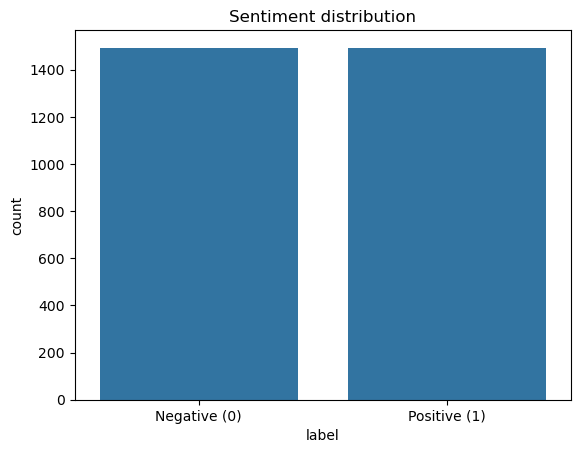

In [16]:
# bar plot to check label distribution
sns.countplot(x="label", data=df_data)
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.title("Sentiment distribution")
plt.show()

##### **Result Interpretation**
The dataset now contains nearly equal proportions of positive (1) and negative (0) reviews, indicating that the data is well-balanced for supervised machine learning. A balanced label distribution is important because it helps prevent the model from becoming biased toward one class and ensures fairer performance across positive and negative sentiments.

#### **Sources Distribution**
Let's check distribution of sources in our dataset.

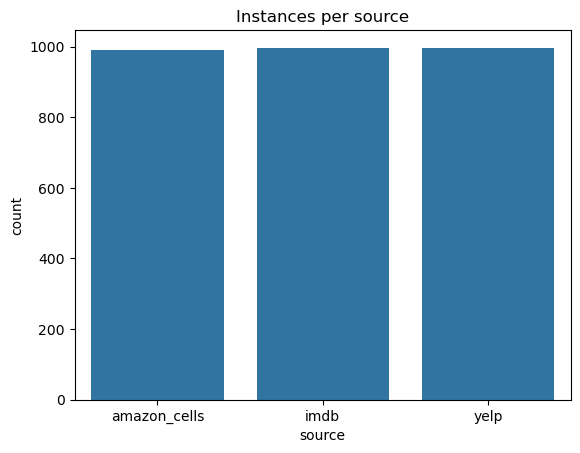

In [17]:
sns.countplot(x="source", data=df_data)
plt.title("Instances per source")
plt.show()

##### **Result Interpretation**
The distribution across data sources shows that the dataset is perfectly balanced.

#### **Sentence-Length Distribution**
Understanding sentence-length distribution is useful for preprocessing and modelling decisions e.g. ensuring tokenization performs correctly on short sentences and that vectorisation methods like TF-IDF remain effective across varying sentence lengths. 


Sentence length summary (words):
count    2983.000000
mean       11.874288
std         7.867742
min         1.000000
25%         6.000000
50%        10.000000
75%        16.000000
max        71.000000
Name: word_len, dtype: float64


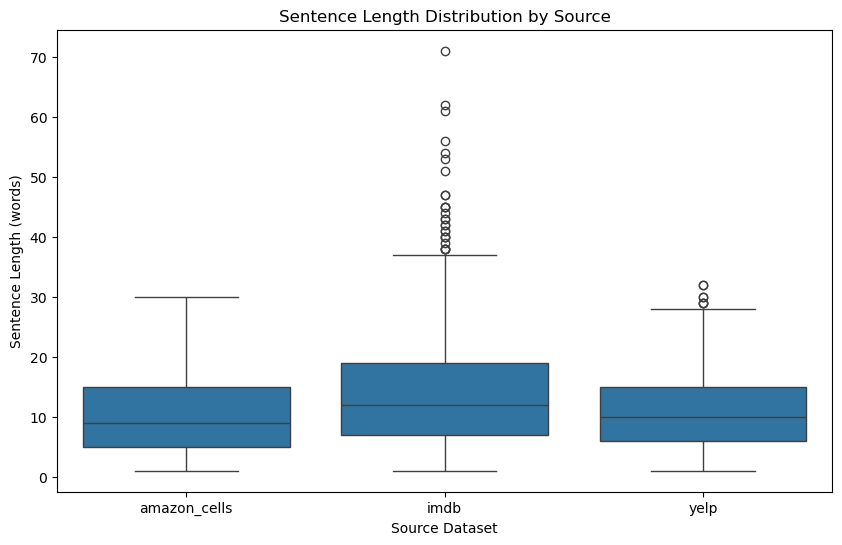

In [18]:
df_data["word_len"] = df_data["sentence"].str.split().str.len()

print("\nSentence length summary (words):")
print(df_data["word_len"].describe())
    
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_data, x="source", y="word_len")
plt.title("Sentence Length Distribution by Source")
plt.xlabel("Source Dataset")
plt.ylabel("Sentence Length (words)")
plt.show()

##### **Result Interpretation**
The average sentence length is approximately 12 words, with most sentences ranging between 6 and 16 words. The shortest sentences contain just 1 word, while the longest reach up to 71 words, indicating substantial variability in writing style.
- Amazon sentences are the shortest and most concise. They have the lowest median length and fewer outliers, reflecting the direct and simple nature of product review language.
- IMDB sentences are the longest and most variable. They show the highest median word count and many long outliers, indicating more detailed, narrative-style writing.
- Yelp sentences fall in the middle. Their median length is slightly higher than Amazon’s but much lower than IMDB’s, with moderate variability.

Overall, the results show that each dataset has distinct linguistic characteristics. Amazon reviews tend to be short and straightforward, IMDB reviews are more descriptive and complex and Yelp reviews sit between the two.

### **Exploratory Text Analysis using Wordclouds**
Let us visualize the most common used words in positive and negative sentences before preprocessing. This will give an overview of words that dominate positive and negative reviews.

In [19]:
!pip install wordcloud

In [20]:
from wordcloud import WordCloud

# helper function for plotting a word cloud
def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

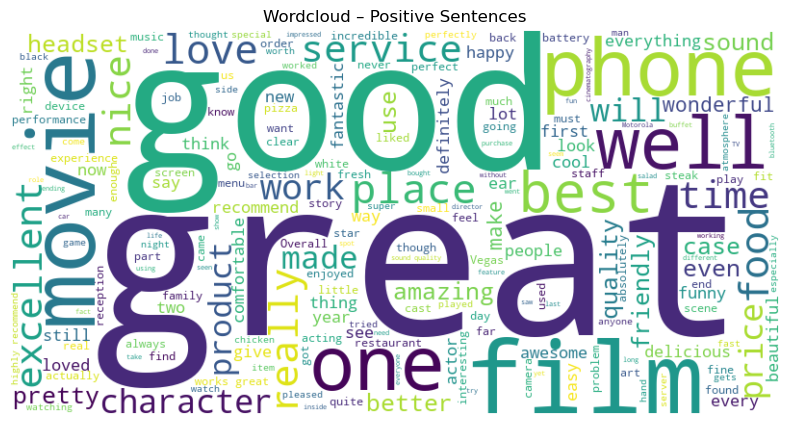

In [21]:
# string of all positive sentences
positive_text = " ".join(df_data[df_data["label"] == 1]["sentence"])

# generate the wordcloud images
plot_wordcloud(positive_text, "Wordcloud – Positive Sentences")

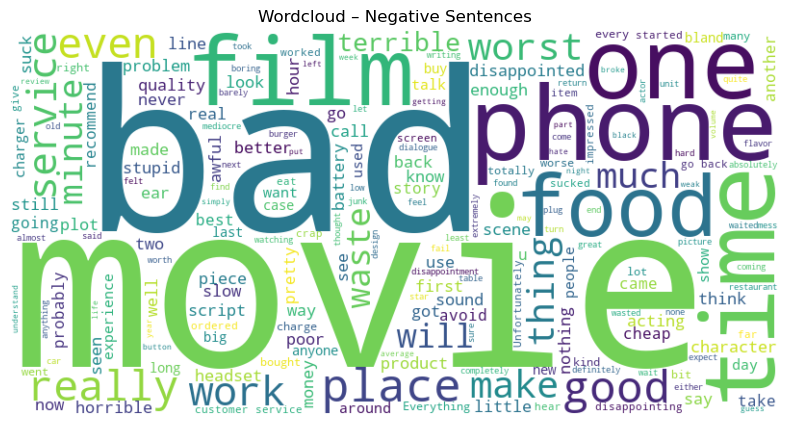

In [22]:
# string of all negative sentences
negative_text = " ".join(df_data[df_data["label"] == 0]["sentence"])

# generate the wordcloud images
plot_wordcloud(negative_text, "Wordcloud – Negative Sentences")

#### **Result Interpretation**
The wordclouds provide an intuitive visual overview of the vocabulary associated with positive and negative reviews across the three domains. Positive reviews frequently include words such as great, good, love and excellent, which reflect strong expressions of satisfaction. Similarly, negative reviews highlight terms like bad, terrible, awful and waste, revealing clear dissatisfaction among users. Domain-specific terms also appear such as phone, battery, movie, plot and food, indicating that each source (Amazon, IMDb, Yelp) contributes its own contextual vocabulary. These visualisations help confirm the validity of the dataset’s sentiment labels and highlight linguistic patterns that justify further preprocessing steps before model training.

## **Text Preprocessing**
Text preprocessing is a crucial step because raw text is often messy, inconsistent and difficult for machine-learning models to interpret directly. Real-world text contains noise such as punctuation, mixed casing, domain-specific words, typos and irrelevant tokens.

By applying preprocessing steps such as lowercasing, tokenisation, stopword removal and lemmatization, we transform the text into a clean, standardised and machine-readable format.

This improves the model’s ability to detect meaningful linguistic patterns, reduces vocabulary size, and ultimately enhances both the accuracy and efficiency of the sentiment-classification model.

In [23]:
# importing NLTK tools
import nltk
from nltk.tokenize import RegexpTokenizer

### **Tokenization Setup**
Let's create a tokenizer that extracts only alphabetic words and apostrophes. It removes punctuation, numbers, emojis etc.

In [24]:
# tokenization setup
tokenizer = RegexpTokenizer(r"[A-Za-z']+")

### **Stopword Setup**
This loads common English stopwords like the, is, at, and, which carry little meaning for sentiment analysis.

In [25]:
from nltk.corpus import stopwords

# stopword setup
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

print(stop_words)

{'more', 'only', "she'll", 'just', 'here', 'all', 'not', 'yourself', 'had', 'against', 'by', "should've", 'mightn', 'now', 'same', 'through', 'he', 'into', "couldn't", "doesn't", 'no', 're', 'as', "mightn't", 'above', 'with', 'has', 'when', 'ours', 'what', 'until', 'nor', "they'd", "don't", "needn't", "i'm", 'be', 'she', 'ain', 'for', 'shouldn', 'why', 'hers', "that'll", 'hadn', "they'll", 'which', 'these', 'will', 'other', 'they', 'it', 'his', 'm', 'being', 'over', 'so', 'me', 'theirs', "hadn't", 'my', 'to', 'yourselves', 'isn', 'if', 'that', 'who', 'its', 'them', 'and', 'mustn', 'haven', 'few', 'each', "he's", 've', "you're", "aren't", 'don', 'the', 'myself', 'those', "we've", 'doesn', 'too', 'is', 'in', 'weren', 'your', 'off', 'a', "we'll", "you'll", 'won', 'under', 'during', 'because', 'yours', 'but', 'her', 'below', 'should', 'll', 'then', 'very', "she's", 'there', "you've", 'any', 'did', 'after', "it'll", 'further', "he'd", "wasn't", 'where', 'does', "you'd", 'once', 'out', "shan

[nltk_data] Downloading package stopwords to C:\Users\HP 1040 X360
[nltk_data]     G5\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Add Domain-Specific Stopwords**
Let's add words that appear frequently because they are domain names not because they express sentiment e.g. movie appears in both positive and negative sentences which is a weak signal for sentiment and we need to remove it.

In [26]:
# remove some domain-specific noise words (product / platform names)
extra_stopwords = {
    "phone", "tablet", "movie", "film", "restaurant", "imdb", "amazon", "yelp"
}

stop_words.update(extra_stopwords)

### **Lemmatization Setup**
Lemmatization converts words to their base form. This reduces vocabulary size and improves model learning.

In [27]:
from nltk.stem import WordNetLemmatizer

# lemmatization setup
lemmatizer = WordNetLemmatizer()

### **POS Tag Conversion Helper**
WordNetLemmatizer needs correct POS (Part-Of-Speech) tags to lemmatize correctly.

In [28]:
# POS tag conversion helper
def get_wordnet_pos(tag):
    """
    Map POS tag to first character that WordNetLemmatizer accepts.
    """
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

### **POS-Aware Lemmatization Pipeline**
The preprocess_text() function standardises each sentence into a clean and machine-readable format. It performs several essential transformations:
- *Convert to lowercase* – ensures consistent text and avoids treating e.g. “Great” and “great” as different words.
- *Tokenisation* – splits text into individual words while removing punctuation using a regular-expression tokenizer.
- *Stopword removal* – removes common words (e.g. “the”, “is”, “and”) and domain-specific noise terms that do not contribute to sentiment.
- *POS tagging* – assigns grammatical roles (noun, verb, adjective, adverb) to each token using NLTK’s part-of-speech tagger.
- *Lemmatization using POS* – converts each word to its base dictionary form (e.g. “running” to “run”, “better” to “good”) improving consistency and reducing sparsity.

Together, these steps remove noise, reduce vocabulary size and preserve meaningful sentiment-bearing words, resulting in a clean version of each sentence that is better suited for TF-IDF vectorisation and model training.

In [29]:
from nltk.corpus import wordnet

def preprocess_text(text: str) -> str:
    """
    Lowercase, tokenize, remove stopwords, apply POS-tagged lemmatization.
    Returns a cleaned string.
    """
    # lower case
    text = text.lower()
    
    # tokenize
    tokens = tokenizer.tokenize(text)
    
    # remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    if not tokens:
        return ""
    
    # POS tagging
    pos_tags = nltk.pos_tag(tokens)
    
    # lemmatization with POS
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for (word, tag) in pos_tags
    ]
    
    return " ".join(lemmatized_tokens)

In [30]:
# check for duplicates
df_data["sentence"].str.lower().duplicated().sum()

3

In [31]:
# check duplicate rows
dupes = df_data[df_data["sentence"].str.lower().duplicated(keep=False)]
dupes.sort_values("sentence")

,sentence,label,source,word_len
290,Great Phone.,1,amazon_cells,2
568,Great Product.,1,amazon_cells,2
647,Great phone.,1,amazon_cells,2
768,Great product.,1,amazon_cells,2
56,VERY DISAPPOINTED.,0,amazon_cells,2
143,very disappointed.,0,amazon_cells,2


In [32]:
# structure of data before dropping duplicates
print("\nShape before dropping duplicates:", df_data.shape)

# drop duplicates
df_data = df_data.loc[~df_data["sentence"].str.lower().duplicated()]

# structure of data after dropping duplicates
print("Shape after dropping duplicates:", df_data.shape)


Shape before dropping duplicates: (2983, 4)
Shape after dropping duplicates: (2980, 4)


#### **Result Interpretation**
We found that some reviews appeared more than once in the dataset but only differed in capitalisation. Because duplicated sentences can distort model learning by giving repeated importance to the same content, we removed them. As a result, the dataset was reduced by three rows.

### **Applying Text Preprocessing**
Let's now apply the preprocess_text() function to every sentence in our dataset. The function performs several cleaning operations like lowercasing, tokenisation, stopword removal and POS-tagged lemmatisation and by running it across the entire sentence column, we generate a new, standardised version of each review. The output is stored in a new column called clean_sentence, which will be used later for TF-IDF vectorisation and model training.

In [33]:
# apply preprocessing
df_data["clean_sentence"] = df_data["sentence"].apply(preprocess_text)

df_data.head()

,sentence,label,source,word_len,clean_sentence
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,amazon_cells,21,way plug u unless go converter
1,"Good case, Excellent value.",1,amazon_cells,4,good case excellent value
2,Great for the jawbone.,1,amazon_cells,4,great jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,amazon_cells,11,tie charger conversation last minute major problem
4,The mic is great.,1,amazon_cells,4,mic great


#### **Clean-up**
Let's check for sentences where, after preprocessing, the cleaned text is empty.

In [34]:
# check cleaned sentences where length is 1 or less
df_data[df_data["clean_sentence"].str.len() < 1]

,sentence,label,source,word_len,clean_sentence
1063,10/10,1,imdb,1,
1883,Don't do it!!!!,0,yelp,3,


In [35]:
df_data["clean_len"] = df_data["clean_sentence"].str.split().str.len()

# inspect empty rows
to_remove = df_data[df_data["clean_len"] == 0]
display(to_remove)

# remove only empty cleaned sentences
df_data = df_data[df_data["clean_len"] > 0].copy()

,sentence,label,source,word_len,clean_sentence,clean_len
1063,10/10,1,imdb,1,,0
1883,Don't do it!!!!,0,yelp,3,,0


In [36]:
# inspect structure of the dataset before and after removing empty sentences
print("Shape after removing empty sentences:", df_data.shape)
display(df_data[["sentence", "clean_sentence"]].head())

Shape after removing empty sentences: (2978, 6)


,sentence,clean_sentence
0,So there is no way for me to plug it in here in the US unless I go by a converter.,way plug u unless go converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,tie charger conversation last minute major problem
4,The mic is great.,mic great


##### **Result Interpretation**
Some sentences became empty after preprocessing because they contained only punctuation, numbers or stopwords. We removed them because they contain no usable text and they cannot contribute to training a text model. In addition, TF-IDF cannot vectorise empty strings.

### **Wordcloud Visualisation After Text Preprocessing**
We generate the wordcloud again after preprocessing so we can visualise only the meaningful, cleaned sentiment words that will actually feed into the model, without noise from raw text.

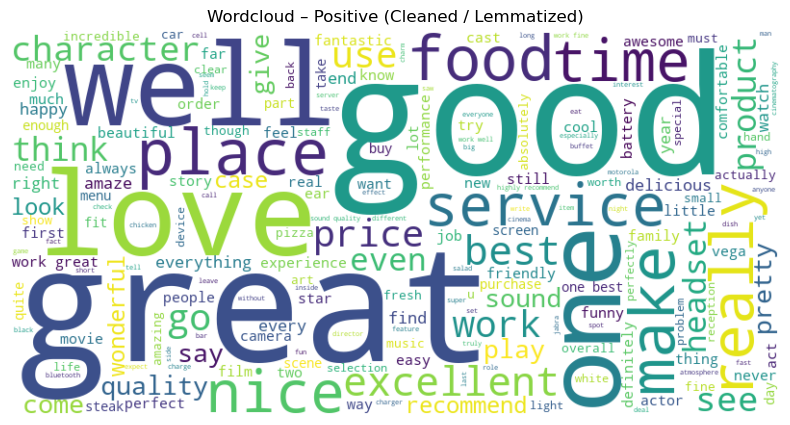

In [37]:
# wordclouds after preprocessing to show sentiment words more clearly
clean_pos_text = " ".join(df_data[df_data["label"] == 1]["clean_sentence"])

plot_wordcloud(clean_pos_text, "Wordcloud – Positive (Cleaned / Lemmatized)")

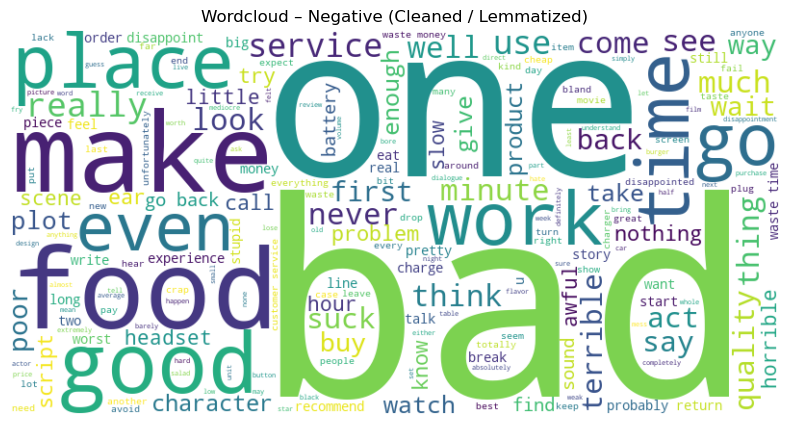

In [38]:
# wordclouds after preprocessing to show sentiment words more clearly
clean_neg_text = " ".join(df_data[df_data["label"] == 0]["clean_sentence"])

plot_wordcloud(clean_neg_text, "Wordcloud – Negative (Cleaned / Lemmatized)")

#### **Result Interpretation**
After preprocessing, the wordclouds now show much more meaningful sentiment-bearing words.

## **TF-IDF vectorisation**
### **Feature Extraction**
In this step, let us convert the cleaned text data into numerical features that a machine learning model can understand. We use TF-IDF to convert each sentence into a vector representing how important each word is within the dataset.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

# initialising TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=2,            # ignore words/phrases that appear only once
    max_df=0.9           # ignore extremely common terms
)

X = tfidf.fit_transform(df_data["clean_sentence"])
y = df_data["label"].values

print("\nTF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (2978, 2634)


#### **Result Interpretation**
After cleaning, removing duplicates and filtering empty rows, we ended up with 2,978 usable sentences and 2,634 unique features (unique words and bigrams).

In [40]:
#convert TF-IDF vectors into a readable table for the first few samples
sample_df = pd.DataFrame(
    X[:5].toarray(), 
    columns=tfidf.get_feature_names_out()
)

sample_df.head()

,ability,able,absolutely,absolutely amaze,absolutely love,abysmal,accept,access,accuse,accuse murder,...,year old,year work,yes,yet,yet another,young,yummy,zero,zero star,zombie
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Class balance check**

In [41]:
# label counts by source
df_data.groupby("source")["label"].value_counts()

source        label
amazon_cells  0        496
              1        491
imdb          0        499
              1        497
yelp          1        499
              0        496
Name: count, dtype: int64

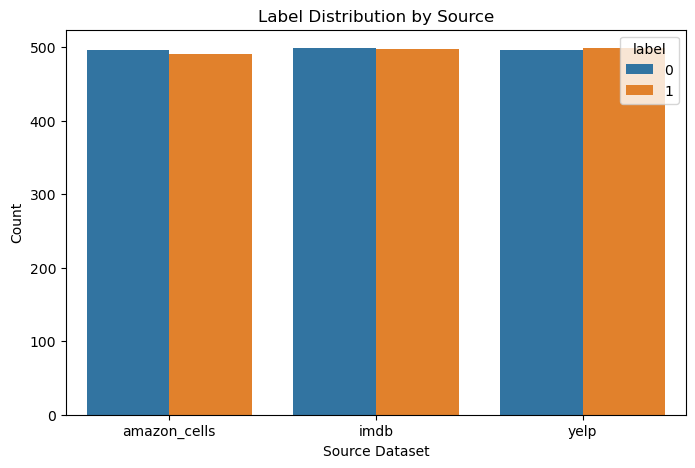

In [42]:
# label distribution by source
plt.figure(figsize=(8, 5))
sns.countplot(data=df_data, x="source", hue="label")
plt.title("Label Distribution by Source")
plt.xlabel("Source Dataset")
plt.ylabel("Count")
plt.show()

#### **Result Interpretation**
After checking the class distribution across sources, the output shows that the sentiment labels (0 = negative, 1 = positive) are well distributed across each of the three datasets Amazon, imdb and Yelp after the data cleaning steps.

Therefore, the dataset remains nearly perfectly balanced between positive and negative reviews confirming that the dataset is fit for training a sentiment classifier model.

## **Classification Model**
We train a classification model because our sentiment analysis is a supervised classification problem. The dataset contains sentences that are already labelled as either negative (0) or positive (1). Our goal is to build a model that can predict which class a new sentence belongs to.

### **Train–test split**
We will split the dataset into train and test sets while simultaneously preserving the corresponding review source labels. This allows the model to be trained on 80% of the data and evaluated on the remaining 20%, while maintaining sentiment balance through stratification. Importantly, splitting the source information enables later analysis of model performance across different domains, which is a key objective of the project.

In [43]:
# save sources
sources = df_data["source"].values

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(X, y, sources, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 2382
Test size : 596


### **Logistic Regression**
We chose Logistic Regression because it performs well on high-dimensional sparse TF-IDF text data, provides interpretable coefficients, trains efficiently and is a strong baseline model for binary sentiment classification.

#### **Model Training**
We now train our sentiment-classification model using Logistic Regression, an appropriate choice for this binary task where the goal is to distinguish between positive and negative sentiment.

In [45]:
from sklearn.linear_model import LogisticRegression

# initialize the model
log_reg = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    C=1.0,
    class_weight=None
)

# train the model on the training data
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

### **Model Evaluation**
After training the model, let's evaluate its performance on the test set to assess how well it generalizes to unseen data.

In [46]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report)

# make predictions on the test set
y_pred = log_reg.predict(X_test)

# calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# test performance summary
print("\nTest performance")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

# detailed per-class metrics
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


Test performance
Accuracy : 0.797
Precision: 0.800
Recall   : 0.792
F1-score : 0.796

Classification report:
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80       298
    Positive       0.80      0.79      0.80       298

    accuracy                           0.80       596
   macro avg       0.80      0.80      0.80       596
weighted avg       0.80      0.80      0.80       596



#### **Result Interpretation**
The classification report confirms that performance is balanced across both classes, with almost identical precision, recall, and F1-score for positive and negative reviews.
- *Accuracy (0.797):* The model predicts sentiment for approximately 80% of reviews in the test set
- *Precision (0.800):* When the model predicts positive, it is correct 80% of the time. This indicates relatively low false positives.
- *Recall (0.792):* The model correctly identifies 79.2% of the actual positive reviews, showing it does not miss many positive cases.
- *F1-score (0.796):* It shows strong overall performance, suggesting neither precision nor recall is dominating at the expense of the other.

Overall, these metrics show that the model generalises well and provides reliable sentiment predictions across unseen reviews.

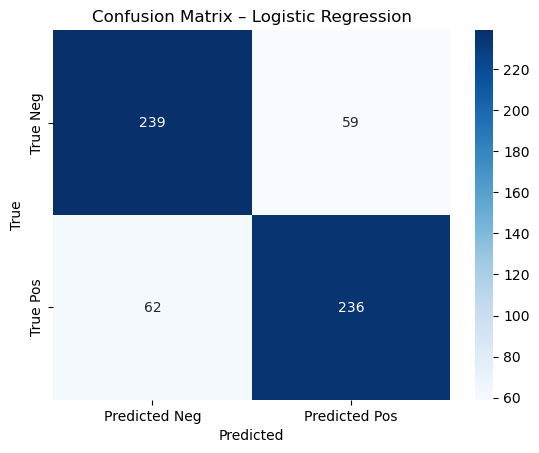

In [47]:
from sklearn.metrics import confusion_matrix

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Neg", "Predicted Pos"],
    yticklabels=["True Neg", "True Pos"]
)
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### **Result Interpretation**
The confusion matrix confirms that the classifier performs almost equally well for both positive and negative classes.

### **Model Evaluation by Source**
Evaluating the model separately on Amazon, IMDb and Yelp reviews helps assess how well the classifier generalises across different domains.

In [48]:
print("\nPerformance by source (on test set)")
results_by_source = []

# evaluate performance separately on Amazon, IMDb and Yelp datasets
for src in sorted(np.unique(src_test)):
    mask = (src_test == src)
    y_true_src = y_test[mask]
    y_pred_src = y_pred[mask]

    # compute metrics
    acc_s = accuracy_score(y_true_src, y_pred_src)
    prec_s = precision_score(y_true_src, y_pred_src)
    rec_s = recall_score(y_true_src, y_pred_src)
    f1_s = f1_score(y_true_src, y_pred_src)

    # store results
    results_by_source.append({
        "source": src,
        "accuracy": acc_s,
        "precision": prec_s,
        "recall": rec_s,
        "f1": f1_s
    })

    # print results
    print(f"\nSource: {src}")
    print(f"  Accuracy : {acc_s:.3f}")
    print(f"  Precision: {prec_s:.3f}")
    print(f"  Recall   : {rec_s:.3f}")
    print(f"  F1-score : {f1_s:.3f}")

# convert the results into a DataFrame for display
results_by_source_df = pd.DataFrame(results_by_source)
display(results_by_source_df)


Performance by source (on test set)

Source: amazon_cells
  Accuracy : 0.830
  Precision: 0.835
  Recall   : 0.826
  F1-score : 0.831

Source: imdb
  Accuracy : 0.805
  Precision: 0.804
  Recall   : 0.787
  F1-score : 0.796

Source: yelp
  Accuracy : 0.763
  Precision: 0.768
  Recall   : 0.768
  F1-score : 0.768


,source,accuracy,precision,recall,f1
0,amazon_cells,0.829670,0.835165,0.826087,0.830601
1,imdb,0.805128,0.804348,0.787234,0.795699
2,yelp,0.762557,0.767857,0.767857,0.767857


#### **Result Interpretation**
The model performs best on Amazon product reviews, achieving an accuracy of 83%, with similarly strong precision, recall and F1-score. This suggests that Amazon reviews contain clearer or more consistent sentiment cues that the model can learn easily.

Performance on IMDb reviews is slightly lower at 80.5% accuracy. Movie-review language is typically more descriptive and narrative-driven, often mixing plot details with subjective opinion. This added complexity and nuance makes sentiment classification more challenging, which explains the reduction in performance compared to Amazon.

The weakest performance occurs on Yelp restaurant reviews, with 76% accuracy. This drop suggests greater linguistic variability in restaurant feedback, possibly containing more context-dependent or ambiguous expressions.

Overall, the model generalises reasonably well across all three domains, but it performs best on shorter, more structured product-review text and struggles more with longer or context-rich sentences found in movie and restaurant reviews.

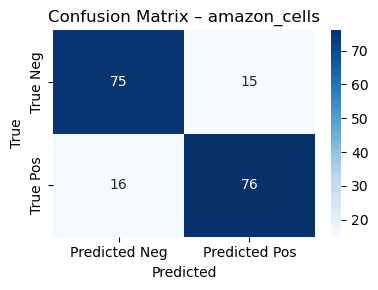

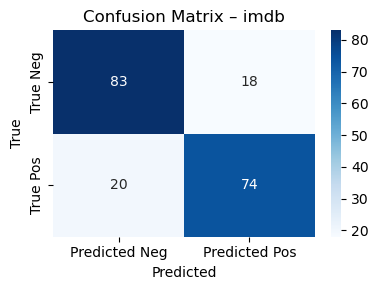

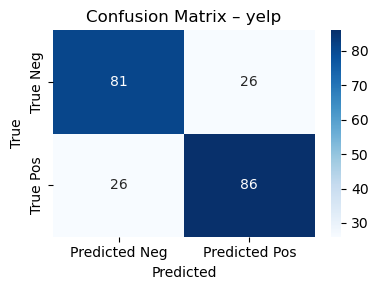

In [49]:
sources_unique = np.unique(src_test)

for src in sources_unique:
    # mask for this source in the test set
    mask = (src_test == src)
    y_true_src = y_test[mask]
    y_pred_src = y_pred[mask]
    
    # compute confusion matrix
    cm_src = confusion_matrix(y_true_src, y_pred_src)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm_src,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Neg", "Predicted Pos"],
        yticklabels=["True Neg", "True Pos"]
    )
    plt.title(f"Confusion Matrix – {src}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### **Linear SVM Classifier**
We selected this as our second model because it is an effective algorithm for high dimensional TF-IDF text data and performs well in sentiment analysis tasks.

#### **Model Training**
Let's train a linear SVM classifier on the TF-IDF features.

In [50]:
from sklearn.svm import LinearSVC

# initialise a linear SVM model
svm_clf = LinearSVC(random_state=42)

# train the SVM on the same training data used for Logistic Regression
svm_clf.fit(X_train, y_train)

LinearSVC(random_state=42)

#### **Model Evaluation**
Next, we evaluate the model on the test data.

In [51]:
# predict sentiment labels for the test set
y_pred_svm = svm_clf.predict(X_test)

# compute evaluation metrics
acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)   # positive class = 1
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)

print("\nLinear SVM – Test Performance")
print(f"Accuracy : {acc_svm:.3f}")
print(f"Precision: {prec_svm:.3f}")
print(f"Recall   : {rec_svm:.3f}")
print(f"F1-score : {f1_svm:.3f}")

print("\nClassification report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=["Negative", "Positive"]))


Linear SVM – Test Performance
Accuracy : 0.797
Precision: 0.786
Recall   : 0.815
F1-score : 0.801

Classification report (SVM):
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79       298
    Positive       0.79      0.82      0.80       298

    accuracy                           0.80       596
   macro avg       0.80      0.80      0.80       596
weighted avg       0.80      0.80      0.80       596



##### **Result Interpretation**
The model achieved an accuracy of 79.7%, with a balanced precision and recall across both sentiment classes. It performs slightly better at identifying positive reviews (recall = 0.82) and slightly better at correctly predicting negative reviews (precision = 0.81). Overall, the model shows stable and consistent performance, with an F1-score of 0.80, indicating reliable sentiment classification on unseen data.

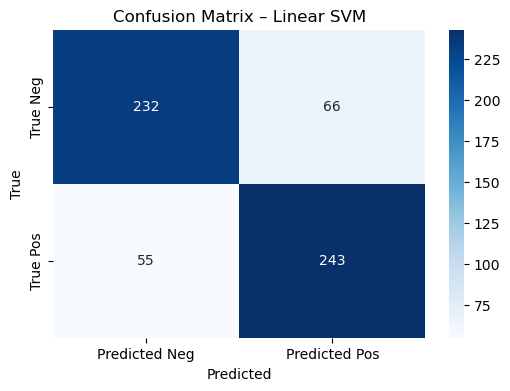

In [52]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Neg", "Predicted Pos"],
    yticklabels=["True Neg", "True Pos"]
)
plt.title("Confusion Matrix – Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##### **Result Interpretation**
The model correctly classified 232 negative reviews and 243 positive reviews. It misclassified 66 negative reviews as positive and 55 positive reviews as negative. This indicates that the model performs slightly better at identifying positive reviews than negative ones. Overall, the confusion matrix reflects stable and reliable sentiment classification performance.

#### **Performance by source (SVM)**

In [53]:
print("\nPerformance by source (Linear SVM, test set)")
results_by_source_svm = []

for src in sorted(np.unique(src_test)):
    # select only test samples from this source
    mask = (src_test == src)
    y_true_src = y_test[mask]
    y_pred_src = y_pred_svm[mask]
    
    # compute metrics for this source
    acc_s = accuracy_score(y_true_src, y_pred_src)
    prec_s = precision_score(y_true_src, y_pred_src)
    rec_s = recall_score(y_true_src, y_pred_src)
    f1_s = f1_score(y_true_src, y_pred_src)
    
    results_by_source_svm.append({
        "source": src,
        "accuracy": acc_s,
        "precision": prec_s,
        "recall": rec_s,
        "f1": f1_s
    })
    
    print(f"\nSource: {src}")
    print(f"  Accuracy : {acc_s:.3f}")
    print(f"  Precision: {prec_s:.3f}")
    print(f"  Recall   : {rec_s:.3f}")
    print(f"  F1-score : {f1_s:.3f}")

results_by_source_svm_df = pd.DataFrame(results_by_source_svm)
display(results_by_source_svm_df)


Performance by source (Linear SVM, test set)

Source: amazon_cells
  Accuracy : 0.830
  Precision: 0.835
  Recall   : 0.826
  F1-score : 0.831

Source: imdb
  Accuracy : 0.790
  Precision: 0.773
  Recall   : 0.798
  F1-score : 0.785

Source: yelp
  Accuracy : 0.776
  Precision: 0.760
  Recall   : 0.821
  F1-score : 0.790


,source,accuracy,precision,recall,f1
0,amazon_cells,0.829670,0.835165,0.826087,0.830601
1,imdb,0.789744,0.773196,0.797872,0.785340
2,yelp,0.776256,0.760331,0.821429,0.789700


##### **Result Interpretation**
The Linear SVM performs best on Amazon product reviews, achieving an F1-score of 0.83, indicating strong accuracy on short, sentiment-heavy sentences. Performance is slightly lower on IMDB reviews, reflecting the more complex and narrative nature of movie-related text. The model performs moderately well on Yelp reviews, with the highest recall in this domain, suggesting it is good at detecting positive sentiment in restaurant feedback but still faces challenges with mixed or context-dependent expressions. 

Overall, SVM generalises well across all three domains while showing predictable variation based on linguistic complexity.

### **Model Comparison**
Let's compare our models logistic regression and linear SVM.

In [54]:
comparison = pd.DataFrame({
    "model": ["Logistic Regression", "Linear SVM"],
    "accuracy": [acc, acc_svm],
    "precision": [prec, prec_svm],
    "recall": [rec, rec_svm],
    "f1": [f1, f1_svm]
})

print("\nOverall model comparison:")
display(comparison)


Overall model comparison:


,model,accuracy,precision,recall,f1
0,Logistic Regression,0.79698,0.800000,0.791946,0.795953
1,Linear SVM,0.79698,0.786408,0.815436,0.800659


#### **Result Interpretation**
Both models achieved almost identical accuracy (79.7%) but their behaviour differs slightly. Logistic Regression produced higher precision, meaning it was more conservative and made fewer false-positive predictions. In contrast, Linear SVM achieved higher recall and a slightly higher F1-score, indicating it was better at capturing true positive sentiment, even if it introduced more false positives. 

Overall, SVM provides a marginal performance advantage, while Logistic Regression remains the more precise and interpretable model.

## **Evaluation of the Output**
The sentiment analysis models produced consistent and reliable results across the three review domains. Both Logistic Regression and Linear SVM achieved an overall accuracy of approximately 80%, indicating that the TF-IDF features combined with linear classifiers were effective for capturing sentiment cues in short text reviews. Logistic Regression demonstrated higher precision, meaning it was more conservative and made fewer false-positive predictions, whereas the Linear SVM model achieved higher recall and a slightly stronger F1-score, showing that it was more sensitive in identifying positive sentiment.

Performance varied by source, reflecting differences in writing style and linguistic complexity. Amazon reviews, which typically contain short and direct opinion statements, achieved the highest scores across models. IMDB reviews, with longer and more narrative language, were slightly more difficult for both models. Yelp reviews showed the most mixed results due to multi-aspect sentiment but SVM handled them reasonably well. Overall, the outputs indicate that the models generalise well and can support practical sentiment-analysis applications, while also highlighting domain-specific challenges where more advanced models or domain adaptation could further enhance performance.

### **Business Insights and Recommendations**
Based on the model results and sentiment-analysis insights, businesses can leverage these findings in several ways:
- *Improve customer experience through automated sentiment monitoring:* The model can automatically classify incoming customer feedback to allow businesses to detect negative sentiments early and respond proactively to issues like product faults and dissatisfaction.
- *Prioritise complaints and route them to the right teams:* Negative reviews identified by the model can be automatically categorised by theme e.g. quality, customer service and forwarded to the relevant department reducing response time and improving customer satisfaction
- *Strengthen product and service improvements:* By analysing recurring negative keywords, companies can identify consistent pain points and use them to guide product redesigns, menu updates etc.
- *Enhance marketing and sales strategies:* Positive keywords can inform marketing campaigns by highlighting what customers value most. This allows brands to align their messaging with authentic customer feedback.
- *Benchmark sentiment across platforms:* Since sentiments vary across sources, businesses can track which platforms have the strongest positive and negative sentiments. This helps allocate resources efficiently to platforms with weaker sentiments.
- *Guide staff training:* For restaurants, negative yelp sentences help reveal gaps on slow service, long wait times etc. These insights can be used to refine training programs and improve service quality.

## **Conclusion**
Our project successfully developed and evaluated sentiment analysis models. The analysis revealed meaningful differences between review domains. Product reviews are the easiest to classify due to their direct language, while movie and restaurant reviews introduce linguistic complexity that slightly reduces accuracy. Nonetheless, both models demonstrated robust generalisation and consistent performance across classes.

The results highlight the practical value of sentiment analysis for organisations seeking to understand customer opinions at scale. By leveraging these models, businesses can monitor sentiment trends, improve customer experience, identify operational issues and make data-driven decisions.